# 0DTE nearest-OTM straddle, every 30-min bar

This notebook is **not** the paper 15:30→close book
(`atm_straddle_rv_iv.ipynb`). It is one explicit choice of two
intraday extensions, spelled out before any table.

## Choice 1 — hold vs re-pick (instrument)

| | **Hold** (path of one straddle) | **Re-pick** (**this notebook**) |
|---|---|---|
| strikes | pick once, keep $K$ all day | new nearest-OTM at every 30-min bar $t$ |
| $R_t$ | 30-min mid path of **those** $K$; last bar cash-settles | next mid of the **$t$-straddle**; 16:00 cash-settles **that** straddle |
| what it is | scalar expansion of one trade | a sequence of 30-min straddles |

**Proper $R_t$.** Pair the return with the forecast window.

- Re-pick + next-bar $\widehat{RV}_t$: $R_t =$ next mid of the straddle
  picked at $t$, divided by entry, minus 1. That is a 30-min hold.
  16:00 has no next mid — cash-settle is a **different** payoff; park
  it or score it as a last-bar settlement book, not as a 30-min hold.
- The paper book cash-settles at the official close. This notebook's
  15:30 row marks to the 16:00 mid. Those are not the same $R$.
  Score both; do not substitute.

This notebook **re-picks**. It does not mark one straddle through the
day.

## Choice 2 — IV (same window as $\widehat{RV}$)

$\widehat{RV}_t$ is next-**30-min** realized variance (smeared
one-bar-ahead $y$). Implied variance has to live on that same window.

| pairing | implied variance | forecast | when it is right |
|---|---|---|---|
| **30-min hold** (this notebook) | $\mathrm{IV}_{30}^{2}=(\mathrm{IV}^{\mathrm{hr}})^{2}/2$ | next-bar $\widehat{RV}_t$ | vendor quote is a 1-hour vol; hold is 30 min |
| remaining-session VRP | $(\mathrm{IV}^{\mathrm{hr}})^{2}\cdot h_t$ with $h_t$ hours left | **remaining** RV, not next-bar $\widehat{RV}$ | hold to close |

At **15:30** the remaining window **is** 30 min, so the two pairings
coincide — that is the paper. At **10:00** they do not: remaining
session is ~6 hours; next-bar $\widehat{RV}$ is 30 min. Using
$\mathrm{IV}^{2}/2$ at 10:00 is the 30-min pairing, **not**
remaining-session VRP.

Hourly IV of the two legs is $(\mathrm{IV}_c+\mathrm{IV}_p)/2$ — equal-weight
on the two contracts, same as the close book.

## Choice 3 — 9:30

The cash session opens at 9:30. This tape has the 9:30 bar and **no**
vendor `underlying_price` (0% finite). `^GSPC` Open **is** the 9:30
cash print and can be $S_{9:30}$. Live mids at 9:30 exist on only
~40% of days, so a GSPC-Open ATM straddle is a **sparse** extra bar,
not a full panel. Default scored book starts at 10:00 (vendor $S$
live). A diagnostic below tries Open anyway.

In [1]:
import os
import sys
from pathlib import Path
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import yfinance as yf

sys.path.insert(0, str(Path.cwd() if (Path.cwd() / "atm_straddle_lib.py").exists() else Path.cwd() / "notebooks"))
import atm_straddle_lib as asl

REPO = asl.find_repo(Path.cwd())
OUT = REPO / "results" / "atm_straddle_intraday"
OUT.mkdir(parents=True, exist_ok=True)
CACHE = OUT / "cache"
CACHE.mkdir(parents=True, exist_ok=True)
print("repo:", REPO)
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", lambda x: f"{x: .6f}")


repo: C:\Users\james\CC Allowed\harxhar-0dte-professor


## 1. Load the 0DTE chain (every 30-min bar)

In [2]:
path = REPO / "data" / "spxw_chain.parquet"
COLS = ["expiration", "timestamp", "strike", "cp", "bid", "ask", "mid",
        "underlying_price", "impl_volatility"]
opt = ["hours_to_expiration"]
import pyarrow.parquet as pq
avail_cols = set(pq.ParquetFile(path).schema_arrow.names)
keep_cols = [c for c in COLS + opt if c in avail_cols]
_st = os.stat(path)
_ck = CACHE / f"chain_0dte_{_st.st_size}_{_st.st_mtime_ns}.parquet"
if _ck.exists():
    chain = pd.read_parquet(_ck)
    print("cache hit", _ck.name)
else:
    raw = pd.read_parquet(path, columns=keep_cols)
    raw["timestamp"] = pd.to_datetime(raw["timestamp"], utc=True)
    raw["expiration"] = pd.to_datetime(raw["expiration"])
    raw["cp"] = raw["cp"].astype(str).str.upper().str[0]
    codes, uts = pd.factorize(raw["timestamp"])
    uet = pd.DatetimeIndex(uts).tz_convert("America/New_York")
    raw["et"] = uet.take(codes)
    raw["et_date"] = uet.normalize().take(codes)
    ecodes, uexp = pd.factorize(raw["expiration"])
    uexp_d = pd.DatetimeIndex(uexp).tz_localize("America/New_York", ambiguous="NaT", nonexistent="NaT").normalize()
    raw["exp_date"] = uexp_d.take(ecodes)
    raw["is_0dte"] = raw["et_date"] == raw["exp_date"]
    chain = raw[raw["is_0dte"]].copy()
    for old in CACHE.glob("chain_0dte_*.parquet"):
        old.unlink()
    chain.to_parquet(_ck)
print("0DTE rows", f"{len(chain):,}")
et0 = pd.to_datetime(chain["et"])
print("clock times", sorted(et0.dt.strftime("%H:%M").unique()))
print(chain.head(3))


cache hit chain_0dte_77439812_1786671584951439500.parquet
0DTE rows 8,198,778


clock times ['09:30', '10:00', '10:30', '11:00', '11:30', '12:00', '12:30', '13:00', '13:30', '14:00', '14:30', '15:00', '15:30', '16:00']
  expiration                 timestamp       strike cp         bid         ask         mid  underlying_price  impl_volatility  hours_to_expiration  \
0 2020-01-03 2020-01-03 14:30:00+00:00  2665.000000  C         NaN         NaN         NaN               NaN              NaN             6.500000   
1 2020-01-03 2020-01-03 15:00:00+00:00  2665.000000  C  570.599976  574.900024  572.750000       3237.649902         0.025000             6.000000   
2 2020-01-03 2020-01-03 15:30:00+00:00  2665.000000  C  570.099976  574.099976  572.099976       3237.679932         0.000500             5.500000   

                         et                   et_date                  exp_date  is_0dte  
0 2020-01-03 09:30:00-05:00 2020-01-03 00:00:00-05:00 2020-01-03 00:00:00-05:00     True  
1 2020-01-03 10:00:00-05:00 2020-01-03 00:00:00-05:00 2020-01-03 00:00:00-05:0

## 2. Regular hours; drop half-sessions

In [3]:
et = pd.to_datetime(chain["et"])
mins = et.dt.hour * 60 + et.dt.minute
rth = (mins >= 9 * 60 + 30) & (mins <= 16 * 60)
chain = chain[rth].copy()
if "hours_to_expiration" in chain.columns:
    open_hte = (
        chain[(et.dt.hour == 9) & (et.dt.minute == 30)]
        .groupby("expiration")["hours_to_expiration"].median()
    )
    half = open_hte[np.abs(open_hte.astype(float) - 6.5) > 0.2].index
    print("half-sessions dropped", len(half))
    chain = chain[~chain["expiration"].isin(half)].copy()
print("rows after RTH filter", f"{len(chain):,}", "days", chain["expiration"].nunique())


half-sessions dropped 12


rows after RTH filter 8,107,358 days 1279


## 2b. Why the scored book starts at 10:00, and `^GSPC` Open as $S_{9:30}$

Vendor `underlying_price` at 9:30 is **all NaN** — the picker has no
$S$ to choose $K_c\ge S$, $K_p\le S$. That is not a 10:00 cash open.

`^GSPC` daily Open **is** the 9:30 cash print. It can fill $S_{9:30}$.
It is a **different** series than the vendor underlying used from
10:00 on (median $|$10:00 vendor $S$ − Open$|$ is several index
points, which is the 9:30→10:00 move, not a bug). The close book uses
vendor $S$ at 15:30 and yfinance only for **settlement**. Mixing Open
at 9:30 with vendor $S$ later is a documented splice, not the paper
protocol.

The binding constraint is quotes, not spot: live 9:30 mids exist on
only about 40% of expiration days. The diagnostic below counts how
many ATM straddles Open would actually form. They are **not** in the
default scored panel.

In [4]:
def load_gspc_ohlc(days):
    days = pd.to_datetime(days)
    cp = CACHE / "gspc_ohlc.parquet"
    if cp.exists():
        ohlc = pd.read_parquet(cp)
        ohlc.index = pd.to_datetime(ohlc.index)
        if ohlc.index.min() <= pd.Timestamp(days.min()) and ohlc.index.max() >= pd.Timestamp(days.max()):
            return ohlc
    raw = yf.download(
        "^GSPC",
        start=pd.Timestamp(days.min()) - pd.Timedelta("7D"),
        end=pd.Timestamp(days.max()) + pd.Timedelta("7D"),
        auto_adjust=True, progress=False, threads=True,
    )
    op, cl = raw["Open"].squeeze(), raw["Close"].squeeze()
    if isinstance(op, pd.DataFrame):
        op = op.iloc[:, 0]
    if isinstance(cl, pd.DataFrame):
        cl = cl.iloc[:, 0]
    out = pd.DataFrame({"open": op.to_numpy(float), "close": cl.to_numpy(float)}, index=op.index)
    ix = pd.to_datetime(out.index)
    if getattr(ix, "tz", None) is not None:
        ix = ix.tz_convert("America/New_York").tz_localize(None)
    out.index = ix.normalize()
    out.to_parquet(cp)
    return out.astype(float)

et = pd.to_datetime(chain["et"])
hh, mm = et.dt.hour, et.dt.minute
exp_day = pd.to_datetime(chain["expiration"])
if getattr(exp_day.dt, "tz", None) is not None:
    exp_day = exp_day.dt.tz_convert("America/New_York").dt.tz_localize(None)
exp_day = exp_day.dt.normalize()
ohlc = load_gspc_ohlc(exp_day)
s930 = chain[(hh == 9) & (mm == 30)]
print("9:30 rows", len(s930), "days", s930["expiration"].nunique())
print("9:30 vendor underlying finite", float(np.isfinite(s930["underlying_price"]).mean()))
print("9:30 mid>0 fraction", float((np.isfinite(s930["mid"]) & (s930["mid"] > 0)).mean()))
live930 = s930[np.isfinite(s930["mid"]) & (s930["mid"] > 0)].copy()
live930["exp_day"] = exp_day.loc[live930.index]
live930["S_open"] = live930["exp_day"].map(ohlc["open"])
live930 = live930[np.isfinite(live930["S_open"])]
c = live930[live930["cp"] == "C"].copy()
p = live930[live930["cp"] == "P"].copy()
c["S"] = c["S_open"]
p["S"] = p["S_open"]
c_otm = c[c["strike"] >= c["S"]].copy()
p_otm = p[p["strike"] <= p["S"]].copy()
c_otm["k_gap"] = c_otm["strike"].astype(float) - c_otm["S"]
p_otm["k_gap"] = p_otm["S"] - p_otm["strike"].astype(float)
c_pick = c_otm.sort_values(["expiration", "k_gap", "strike"]).groupby("expiration", as_index=False).first()
p_pick = p_otm.sort_values(["expiration", "k_gap", "strike"]).groupby("expiration", as_index=False).first()
both930 = c_pick.merge(p_pick, on="expiration", suffixes=("_c", "_p"))
print("days with any live 9:30 mid", live930["expiration"].nunique(), "/", s930["expiration"].nunique())
print("9:30 ATM straddles if S = GSPC Open", len(both930))
s10 = chain[(hh == 10) & (mm == 0)].dropna(subset=["underlying_price"])
s10m = s10.groupby(exp_day.loc[s10.index])["underlying_price"].first()
common = s10m.index.intersection(ohlc.index)
gap = (s10m.loc[common] - ohlc.loc[common, "open"]).abs()
print("|10:00 vendor S - GSPC Open| median", float(gap.median()), "n", len(common))
print("default book does not include these 9:30 straddles.")


9:30 rows 579097 days 1279
9:30 vendor underlying finite 0.0
9:30 mid>0 fraction 0.3552824483635729


days with any live 9:30 mid 519 / 1279
9:30 ATM straddles if S = GSPC Open 518


|10:00 vendor S - GSPC Open| median 8.51025390625 n 1279
default book does not include these 9:30 straddles.


## 3. Nearest-OTM straddle at each 30-min bar (re-pick; vendor $S$ only)

In [5]:
_book_ck = CACHE / f"book_{_st.st_size}_{_st.st_mtime_ns}.parquet"
if _book_ck.exists():
    pkg = pd.read_parquet(_book_ck)
    live = None
    print("book cache hit", _book_ck.name, "straddles", len(pkg), "days", pkg["expiration"].nunique())
    print(pkg[["expiration", "timestamp", "S", "K_c", "K_p", "entry"]].head())
else:
    live = chain[np.isfinite(chain["mid"]) & (chain["mid"] > 0)]
    spot = asl.stamp_spot(live, ["expiration", "timestamp"])
    print("times with a spot", len(spot), "all-NaN times get no S and form no straddle (9:30)")
    spot_df = spot.rename("S").reset_index()
    c = live.loc[live["cp"] == "C", ["expiration", "timestamp", "strike", "mid", "impl_volatility"]].merge(
        spot_df, on=["expiration", "timestamp"], how="left")
    p = live.loc[live["cp"] == "P", ["expiration", "timestamp", "strike", "mid", "impl_volatility"]].merge(
        spot_df, on=["expiration", "timestamp"], how="left")
    n_c_nos = int((~np.isfinite(c["S"])).sum())
    n_p_nos = int((~np.isfinite(p["S"])).sum())
    print("live rows dropped for missing S: calls", n_c_nos, "puts", n_p_nos)
    c = c[np.isfinite(c["S"])]
    p = p[np.isfinite(p["S"])]
    BAND = 100.0
    c_near = c[(c["strike"] >= c["S"]) & (c["strike"] <= c["S"] + BAND)].copy()
    c_near["k_gap"] = c_near["strike"].astype(float) - c_near["S"]
    c_pick = c_near.loc[c_near.groupby(["expiration", "timestamp"])["k_gap"].idxmin()]
    p_near = p[(p["strike"] <= p["S"]) & (p["strike"] >= p["S"] - BAND)].copy()
    p_near["k_gap"] = p_near["S"] - p_near["strike"].astype(float)
    p_pick = p_near.loc[p_near.groupby(["expiration", "timestamp"])["k_gap"].idxmin()]
    print("bars with OTM call", len(c_pick), "OTM put", len(p_pick))
    pkg = c_pick.merge(p_pick, on=["expiration", "timestamp"], suffixes=("_c", "_p"))
    print("bars with both legs", len(pkg), "call-only", len(c_pick) - len(pkg), "put-only dropped at merge")
    pkg["S"] = pkg["S_c"].astype(float)
    pkg["K_c"] = pkg["strike_c"].astype(float)
    pkg["K_p"] = pkg["strike_p"].astype(float)
    pkg["entry"] = pkg["mid_c"].astype(float) + pkg["mid_p"].astype(float)
    pkg["iv_hourly"] = (
        pd.to_numeric(pkg["impl_volatility_c"], errors="coerce")
        + pd.to_numeric(pkg["impl_volatility_p"], errors="coerce")
    ) / 2.0
    pkg = pkg.sort_values(["expiration", "timestamp"]).reset_index(drop=True)
    print("straddles", len(pkg), "days", pkg["expiration"].nunique())
    print(pkg[["expiration", "timestamp", "S", "K_c", "K_p", "entry"]].head())


times with a spot 16626 all-NaN times get no S and form no straddle (9:30)


live rows dropped for missing S: calls 102873 puts 102870


bars with OTM call 16626 OTM put 16622
bars with both legs 16622 call-only 4 put-only dropped at merge
straddles 16622 days 1279
  expiration                 timestamp            S          K_c          K_p      entry
0 2020-01-03 2020-01-03 15:00:00+00:00  3237.649902  3240.000000  3235.000000  10.750000
1 2020-01-03 2020-01-03 15:30:00+00:00  3237.679932  3240.000000  3235.000000   8.650000
2 2020-01-03 2020-01-03 16:00:00+00:00  3234.679932  3235.000000  3230.000000   8.900000
3 2020-01-03 2020-01-03 16:30:00+00:00  3236.000000  3240.000000  3235.000000   7.100000
4 2020-01-03 2020-01-03 17:00:00+00:00  3241.270020  3245.000000  3240.000000   5.625000


## 4. Exit: next-bar mid of the same strikes; last bar cash-settles

Re-pick 30-min hold: $R_t = \mathrm{exit}_{t+1}/P_t - 1$ with
$\mathrm{exit}_{t+1}$ = next mid of **those** $K$. If a leg is missing
at $t+1$, the row is dropped — counts printed below.

**16:00 / last bar** has no next mid. Cash-settle vs `^GSPC` close
is the paper payoff, applied here to the **16:00 straddle**, not the
15:30 straddle. That row is settlement, not a 30-min hold.

**15:30** in this book is 15:30→**16:00 mid** of the 15:30 $K$. The
paper is 15:30→**official close** of the 15:30 $K$. A cell below
scores always-short both ways on the same 15:30 straddles. Use the
close calculation when comparing to the paper; use next-mid when this
row is one step in the 30-min re-pick path.

In [6]:
if "R" in pkg.columns and _book_ck.exists():
    print("book cache: skip exit rebuild")
    n_pkg = len(pkg)
else:
    pkg["nxt_ts"] = pkg.groupby("expiration")["timestamp"].shift(-1)
    pkg["is_last"] = pkg["nxt_ts"].isna()
    days = pd.to_datetime(pkg["expiration"])
    if getattr(days.dt, "tz", None) is not None:
        days = days.dt.tz_convert("America/New_York").dt.tz_localize(None)
    days = days.dt.normalize()
    ohlc = load_gspc_ohlc(days)
    pkg["S_close"] = days.map(ohlc["close"])
    pkg["exit_settle"] = np.maximum(pkg["S_close"] - pkg["K_c"], 0.0) + np.maximum(pkg["K_p"] - pkg["S_close"], 0.0)
    nxt = pkg.loc[~pkg["is_last"], ["expiration", "nxt_ts", "K_c", "K_p"]].copy()
    left_c = nxt[["expiration", "nxt_ts", "K_c"]].rename(columns={"nxt_ts": "timestamp", "K_c": "strike"})
    left_p = nxt[["expiration", "nxt_ts", "K_p"]].rename(columns={"nxt_ts": "timestamp", "K_p": "strike"})
    quotes = live.loc[:, ["expiration", "timestamp", "strike", "cp", "mid"]]
    got_c = left_c.merge(quotes.loc[quotes["cp"] == "C", ["expiration", "timestamp", "strike", "mid"]],
                         on=["expiration", "timestamp", "strike"], how="left")
    got_p = left_p.merge(quotes.loc[quotes["cp"] == "P", ["expiration", "timestamp", "strike", "mid"]],
                         on=["expiration", "timestamp", "strike"], how="left")
    nxt["mid_c_nxt"] = got_c["mid"].to_numpy()
    nxt["mid_p_nxt"] = got_p["mid"].to_numpy()
    pkg = pkg.merge(nxt[["expiration", "nxt_ts", "K_c", "K_p", "mid_c_nxt", "mid_p_nxt"]],
                    on=["expiration", "nxt_ts", "K_c", "K_p"], how="left")
    pkg["exit_mark"] = pkg["mid_c_nxt"] + pkg["mid_p_nxt"]
    n_pkg = len(pkg)
n_last = int(pkg["is_last"].sum())
n_nonlast = n_pkg - n_last
miss_c = (~pkg["is_last"]) & pkg["mid_c_nxt"].isna()
miss_p = (~pkg["is_last"]) & pkg["mid_p_nxt"].isna()
miss_either = (~pkg["is_last"]) & ~np.isfinite(pkg["exit_mark"])
miss_settle = pkg["is_last"] & ~np.isfinite(pkg["exit_settle"])
bad_entry = ~np.isfinite(pkg["entry"]) | (pkg["entry"] <= 0)
print("straddles before exit filter", n_pkg)
print("last-bar (cash-settle path)", n_last)
print("non-last (next-mid path)", n_nonlast)
print("non-last missing next CALL mid", int(miss_c.sum()))
print("non-last missing next PUT mid", int(miss_p.sum()))
print("non-last missing either leg (row would drop)", int(miss_either.sum()),
      f"({100.0 * miss_either.sum() / max(n_nonlast, 1):.2f}% of non-last)")
print("last-bar missing GSPC settle", int(miss_settle.sum()))
print("bad entry (nonfinite or <=0)", int(bad_entry.sum()))

pkg["exit"] = np.where(pkg["is_last"], pkg["exit_settle"], pkg["exit_mark"])
keep = np.isfinite(pkg["entry"]) & np.isfinite(pkg["exit"]) & (pkg["entry"] > 0)
print("dropped at exit filter", int((~keep).sum()), "kept", int(keep.sum()))
pkg = pkg[keep].copy()
pkg["R"] = pkg["exit"] / pkg["entry"] - 1.0
pkg["R_as"] = -pkg["R"]
pkg["et"] = pd.to_datetime(pkg["timestamp"], utc=True).dt.tz_convert("America/New_York")
pkg["hour"] = pkg["et"].dt.hour
pkg["hhmm"] = pkg["et"].dt.strftime("%H:%M")
pkg["date"] = pkg["et"].dt.normalize().dt.tz_localize(None)
if not _book_ck.exists():
    pkg.to_parquet(_book_ck)
    print("wrote book cache", _book_ck.name)
print("bars with a return", len(pkg), "last-bar fraction", float(pkg["is_last"].mean()))
print("always-short R by clock time (no model; long R is the negative)")
as_raw = pkg.groupby("hhmm")["R_as"].agg(["count", "mean", "std", "median"])
as_raw["t"] = as_raw["mean"] / as_raw["std"] * np.sqrt(as_raw["count"])
as_raw["Sharpe_ann"] = as_raw["mean"] / as_raw["std"] * np.sqrt(252.0)
print(as_raw.to_string())


straddles before exit filter 16622
last-bar (cash-settle path) 1279
non-last (next-mid path) 15343
non-last missing next CALL mid 0
non-last missing next PUT mid 0
non-last missing either leg (row would drop) 0 (0.00% of non-last)
last-bar missing GSPC settle 0
bad entry (nonfinite or <=0) 0
dropped at exit filter 0 kept 16622


wrote book cache book_77439812_1786671584951439500.parquet
bars with a return 16622 last-bar fraction 0.07694621585850078
always-short R by clock time (no model; long R is the negative)
       count      mean       std    median          t  Sharpe_ann
hhmm                                                             
10:00   1277  0.007205  0.151417  0.048701   1.700493    0.755405
10:30   1278  0.007297  0.148263  0.045593   1.759407    0.781270
11:00   1278  0.001557  0.135726  0.037640   0.410215    0.182157
11:30   1278  0.011395  0.121808  0.043083   3.344363    1.485074
12:00   1279  0.006863  0.123748  0.037344   1.983404    0.880392
12:30   1279  0.006968  0.125388  0.035644   1.987379    0.882157
13:00   1279  0.007116  0.196838  0.052469   1.292858    0.573873
13:30   1279  0.012318  0.174841  0.059880   2.519539    1.118372
14:00   1279  0.006572  0.252436  0.077369   0.931090    0.413292
14:30   1279  0.026143  0.294782  0.099071   3.171669    1.407839
15:00   1279  0.058902

## 4b. 15:30 next-mid vs 15:30 cash-settle (always-short)

Paper book: 15:30 straddle, exit = official close. This notebook's
15:30 row: same straddle, exit = 16:00 mid. Always-short on both,
same days. The close calculation is the one that matches the paper.

In [7]:
m1530 = (pkg["et"].dt.hour == 15) & (pkg["et"].dt.minute == 30)
p15 = pkg.loc[m1530].copy()
p15["R_mid"] = p15["exit_mark"] / p15["entry"] - 1.0
p15["R_close"] = p15["exit_settle"] / p15["entry"] - 1.0
ok = np.isfinite(p15["R_mid"]) & np.isfinite(p15["R_close"])
p15 = p15.loc[ok]
print("15:30 straddles with both exits", len(p15))
for name, col in (("15:30 -> 16:00 mid (this notebook)", "R_mid"),
                  ("15:30 -> official close (paper)", "R_close")):
    x = -p15[col]  # always short
    mu, sd = float(x.mean()), float(x.std(ddof=1))
    n = int(len(x))
    print(name)
    print(f"  n {n}  mean {mu:.4f}  Sharpe {mu/sd*np.sqrt(252):.3f}  t {mu/sd*np.sqrt(n):.3f}")


15:30 straddles with both exits 1279
15:30 -> 16:00 mid (this notebook)
  n 1279  mean -0.0011  Sharpe -0.016  t -0.036
15:30 -> official close (paper)
  n 1279  mean 0.0246  Sharpe 0.346  t 0.780


## Side question: vendor IV units (Chris hourly)

The chain column is `impl_volatility` (exported as `new_implied_vol`).
OptionMetrics' **manual** says that field is an **annualized** Black–Scholes
vol: ATM SPX should be on the order of $0.20$ ($20\%$). A 30-minute
variance from that reading would be

$$
\sigma_{\mathrm{ann}}^{2}\times\frac{0.5}{252\times 6.5}
\sim 0.04\times 3\times 10^{-4}
\sim 10^{-5}\text{--}10^{-6}
$$

if the $0.20$ were real.

**What is in the file** is $\sim 0.002$ at ATM, not $0.20$ — about
$100\times$ too small to be annualized vol. A $0.2\%$ annualized vol
cannot price a $\sim \$12$ ATM straddle; those mids are $\sim 20\%$ vol.
That size mismatch is the unit tell.

Read $0.002$ as a **1-hour standard deviation** of returns (Chris:
"hourly vol") and the scale matches $\widehat{RV}$:

$$
\mathrm{Var}(1\mathrm{h})=0.002^{2}=4\times 10^{-6},\qquad
\mathrm{Var}(30\mathrm{min})=0.002^{2}\times\tfrac12=2\times 10^{-6}.
$$

Median $\widehat{RV}$ here is $\sim 3.6\times 10^{-6}$. Treat $0.002$ as
OM-annualized and shrink by $1/(252\times 6.5)$ and you get
$\sim 10^{-9}$ (`annualized_om` below) — not comparable to
$\widehat{RV}$. We do not use that.

Hence $\mathrm{IV}_{30}=\mathrm{IV}^{\mathrm{hr}}/\sqrt{2}$ and
$\mathrm{iv\_var}=(\mathrm{IV}^{\mathrm{hr}})^{2}/2$. No inversion from
the mid. Other scripts in the repo ignore the vendor number and invert
BS with $\tau=h_{\mathrm{close}}/(252\times 6.5)$; that is a different
convention.

For the **30-min hold** pairing this notebook uses
$\mathrm{iv\_var}=(\mathrm{IV}^{\mathrm{hr}})^{2}\cdot 0.5$ at every
bar — the same window as next-bar $\widehat{RV}$. That is
remaining-session variance **only** at 15:30, where 30 minutes is what
is left.

In [8]:
iv = pkg["iv_hourly"].astype(float)
print("median vendor IV", float(iv.median()), "median straddle mid", float(pkg["entry"].median()))
conv = asl.iv_var_from_conventions(iv, hours_remaining=0.5)
for k, s in conv.items():
    print(k, "median var", float(s.median()))
print("30-min pairing: iv_var = (IV_hr)^2 * 0.5  [used]")
print("remaining-session pairing would need hours_left * (IV_hr)^2 and remaining RV [not used]")


median vendor IV 0.002681540558114648 median straddle mid 12.550000190734863
chris_hourly median var 3.5953298977349252e-06
annualized_om median var 2.1949510975182697e-09
already_window median var 7.1906597954698504e-06
30-min pairing: iv_var = (IV_hr)^2 * 0.5  [used]
remaining-session pairing would need hours_left * (IV_hr)^2 and remaining RV [not used]


## 5. Forecasts and the smear (same map as the close book)

Close book and this notebook share `second_order_raw` /
`load_yhat_panel`:

1. Forecasts live on $y=\sqrt{RV/B}$. Actual $y$ on each bar:
   $\sqrt{\mathrm{rv\_raw}/B}$.
2. Collapse to **calendar days**: for each day, sum $n,x,x^{2},y,xy,y^{2}$
   over **all 30-min bars** that day (not 15:30-only).
3. Prefix sums. For evaluation day $d\ge 63$, the MZ window is days
   $[d-250,\,d)$ — **prior days only**. Same-day bars are not in the
   window. Require $n\ge 200$ finite bars in that window.
4. Fit $m=a+b\,\widehat{y}$ and residual $\hat\sigma^{2}$ on that
   window. Apply **that day's** $(a,b,\hat\sigma^{2})$ to **each** bar
   $t$ on day $d$:
   $\widehat{RV}_t=(m_t^{2}+\hat\sigma^{2}_d)B_t$.

The close book runs this on the full panel, then **keeps the 15:30
row**. This notebook keeps every row. Coefficients $(a_d,b_d,\hat\sigma^{2}_d)$
are the same object. What changes is which $t$ you score, not how the
smear is fit.

$\widehat{RV}_t$ is $E[RV]$ for the **next 30-min bar**, not remaining
session.

In [9]:
YHATS = asl.yhat_paths(REPO)
LABEL = asl.YHAT_LABEL
MODEL_ORDER = asl.MODEL_ORDER
panels = {}
_blk2 = YHATS["blk2"]
if not _blk2.exists():
    print("missing", _blk2)
else:
    df = asl.load_yhat_panel(_blk2)
    panels["blk2"] = df.set_index("t")[["rv_hat", "yhat", "rv_raw", "baseline"]]
    print("blk2", "bars", len(panels["blk2"]))

pkg["t"] = pd.to_datetime(pkg["timestamp"], utc=True)
work = pkg.copy()
if "blk2" in panels:
    work = work.merge(panels["blk2"].reset_index(), left_on="t", right_on="t", how="left")
work["iv_var_chris"] = (work["iv_hourly"].astype(float) ** 2) * 0.5
work["iv_var_om"] = (work["iv_hourly"].astype(float) ** 2) * 0.5 / (252.0 * 6.5)
work["iv_var_raw"] = work["iv_hourly"].astype(float) ** 2
print("median rv_hat", float(pd.to_numeric(work.get("rv_hat", pd.Series(dtype=float)), errors="coerce").median()))
print("median iv_var chris / om / raw",
      float(work["iv_var_chris"].median()),
      float(work["iv_var_om"].median()),
      float(work["iv_var_raw"].median()))
print("using 30-min pairing (chris). remaining-session pairing is not scored.")
n_pre = len(work)
work["signal"] = work["rv_hat"] - work["iv_var_chris"]
work = work.dropna(subset=["R", "signal"])
print("dropped at forecast join (no yhat / no smear)", n_pre - len(work), "kept", len(work))
work["pos"] = np.where(work["signal"] > 0, 1.0, -1.0)
print("bars after join", len(work), "clock times", sorted(work["hhmm"].unique()))


blk2 bars 276317
median rv_hat 3.898231720256095e-06
median iv_var chris / om / raw 3.5953298977349252e-06 2.1949510975182697e-09 7.1906597954698504e-06
using 30-min pairing (chris). remaining-session pairing is not scored.
dropped at forecast join (no yhat / no smear) 5369 kept 11253
bars after join 11253 clock times ['10:00', '10:30', '11:00', '11:30', '12:00', '12:30', '13:00', '13:30', '14:00', '14:30', '15:00', '15:30', '16:00']


## 6. Rule table — three books (pooled)

Same bars and the same long-straddle $R$ (next-mid 30-min hold;
16:00 cash-settles vs the official close). Only the position $q_t$
changes. One forecast: block-diag ridge (`blk2`). Mid fill.

**Rules** (each returns $R'_t=q_t R_t$):

- **always short:** $q_t\equiv -1$ every bar. No forecast. This is
  the scalar: short every re-picked straddle.
- **long-short volatility:** $q_t=\mathrm{sign}(s_t)$, with
  $s_t=\widehat{RV}_t-\mathrm{IV}_{30,t}^{2}$ and $s_t=0$ mapped to
  $-1$. Long the straddle when the forecast exceeds implied 30-min
  variance, short otherwise. Size is always one straddle.
- **unit-median VRP:**
  $q_t=\mathrm{clip}(s_t/\mathrm{med}_{u<t}|s_u|,-3,3)$.
  Same sign as long-short; size is one lot per causal expanding
  median $|s|$. The median is over **all prior 30-min bars** (not
  15:30-only), lagged one bar (`.shift(1)`), warmup $63\times$
  (median bars per day) $\approx 63$ trading days. Before warmup,
  $\mathrm{med}$ is NaN $\Rightarrow$ leverage $1$. Cap 3.
  Numerator is this bar's $|s_t|$; denominator is only bars
  **strictly before** $t$. 16:00 $|s|$ sits on a different scale
  (cash-settle) and can hit the cap — park that bar for UM.

The table is **pooled**: every clock stacked into one list
($\sim 11{,}254$ rows). Those are $\sim 13$ bars **on the same
day**, not $11{,}254$ separate days.

**How pooled `Sharpe_ann` is computed**

1. For each bar, $R'_t=q_t R_t$ as above.
2. For each calendar day $d$, add the day's bars (non-compounded):
   $R^{day}_d=\sum_{t\in d} R'_t$. One number per expiration day
   (`n_days`).
3. $\mathrm{Sharpe}_{ann}=\overline{R}^{day}/\mathrm{sd}(R^{day})\times\sqrt{252}$.

Not $\overline{R'}/\mathrm{sd}(R')\times\sqrt{252}$ on the stacked
bars (that treats each 30-min row as a full trading day). Not that
quantity times $\sqrt{13}$ (the $\sim 13$ bars on one day are not
13 independent days). Daily collapse is the conversion that
respects same-day dependence. $\sqrt{252}$ is then the same
year-length as the 15:30 paper book.

**Columns.** `mean` through `ex_kurt` are `Series.describe`-style
moments of the **30-min** $R'$ (unannualized). The rest:

- `n` — 30-min bars scored.
- `n_days` — expiration days after the daily sum.
- `mean` — mean 30-min $R'$.
- `mean_daily` — mean of $R^{day}$.
- `std`, `min`, `25%`, `50%`, `75%`, `max` — of 30-min $R'$.
- `skew`, `ex_kurt` — of 30-min $R'$. `ex_kurt` is **excess**
  kurtosis (Fisher; pandas `Series.kurt()`): fourth standardized
  moment minus 3, so a Gaussian scores 0 not 3. Raw (Pearson)
  kurtosis is `ex_kurt + 3`.
- `Sharpe_bar` — $\overline{R'}/\mathrm{sd}(R')$ on the stacked
  30-min rows. No $\sqrt{\,\cdot\,}$. Typical 30-min trade, not
  annual.
- `Sharpe_ann` — annualized Sharpe of the **daily** $R^{day}$
  series, as in the three steps above.
- `t_mean` — $t$-stat of that daily mean,
  $t=\sqrt{n_{\mathrm{days}}}\cdot\overline{R}^{day}/\mathrm{sd}(R^{day})$.
  Uses the raw mean/std, not an extra annualization.
  $t=\mathrm{Sharpe}_{ann}\times\sqrt{n_{\mathrm{days}}/252}$ at
  fixed $n_{\mathrm{days}}$; both are shown so the table reads
  either way.
- `n_buy` / `pct_buy` — bars with $q_t>0$ (buy the straddle).
  Always-short is 0 by construction.

16:00 cash-settle contaminates always-short and UM in this pooled
table. Split by clock is the next section.

In [10]:
work = work.sort_values("t").reset_index(drop=True)
n_bars_per_day = int(work.groupby("date").size().median())
min_bars = int(63 * max(n_bars_per_day, 1))
print("UM expanding median over all prior bars; warmup", min_bars, "bars (~63 days x", n_bars_per_day, "bars/day)")
med_all = asl.lagged_expanding_median(work["signal"], min_periods=min_bars)
work["lev"] = asl.um_leverage_vs_lagged_scale(work["signal"], med_all)
q = {
    "always short": pd.Series(-1.0, index=work.index),
    "long-short volatility": work["pos"],
    "unit-median VRP": work["pos"] * work["lev"],
}
rows = []
for name, size in q.items():
    rp = (size * work["R"]).astype(float)
    st = asl.rule_row(rp, size)
    daily = rp.groupby(work["date"]).sum()
    dmu = float(daily.mean()) if len(daily) else float("nan")
    dsd = float(daily.std(ddof=1)) if len(daily) >= 2 else float("nan")
    sbar = float(st["mean"] / st["std"]) if (st["std"] and st["std"] > 0) else float("nan")
    n_days = int(daily.notna().sum())
    st["Sharpe_bar"] = sbar
    st["n_days"] = n_days
    st["mean_daily"] = dmu
    st["Sharpe_ann"] = (
        dmu / dsd * np.sqrt(252.0) if (dsd and dsd > 0) else float("nan")
    )
    st["t_mean"] = (
        dmu / dsd * np.sqrt(n_days) if (dsd and dsd > 0) else float("nan")
    )
    rows.append({"rule": name, **st.to_dict()})
tab = pd.DataFrame(rows).set_index("rule")
cols = [
    "n", "n_days", "mean", "mean_daily", "std", "min", "25%", "50%", "75%", "max",
    "skew", "ex_kurt", "Sharpe_bar", "t_mean", "Sharpe_ann", "n_buy", "pct_buy",
]
print("pooled (16:00 cash-settle contaminates always-short / UM)")
print("Sharpe_bar = mean/std of 30-min R' (no sqrt)")
print("Sharpe_ann = mean/std of (sum of R' that calendar day) * sqrt(252)")
print("t_mean = mean_daily / sd_daily * sqrt(n_days)")
print(tab[cols].to_string())
tab.to_csv(OUT / "rule_table_intraday_blk2.csv")


UM expanding median over all prior bars; warmup 819 bars (~63 days x 13 bars/day)
pooled (16:00 cash-settle contaminates always-short / UM)
Sharpe_bar = mean/std of 30-min R' (no sqrt)
Sharpe_ann = mean/std of (sum of R' that calendar day) * sqrt(252)
t_mean = mean_daily / sd_daily * sqrt(n_days)
                                  n      n_days      mean  mean_daily       std         min       25%       50%       75%       max       skew      ex_kurt  Sharpe_bar     t_mean  Sharpe_ann        n_buy    pct_buy
rule                                                                                                                                                                                                                  
always short           11253.000000  866.000000  0.078214    1.016332  0.660865  -50.796874 -0.017341  0.059603  0.126984  1.000000 -41.752601  3134.207803    0.118351  13.547028    7.307778     0.000000   0.000000
long-short volatility  11253.000000  866.000000  0.068294

## 7. Always-short by 30-min bar (a clock hour is two bars mashed)

`rule_row` reports
$\mathrm{Sharpe}_{ann}=\overline{R'}/\mathrm{sd}(R')\times\sqrt{252}$.
$\sqrt{252}$ is the year-length for a **daily** series: 252 trading
days, one return per day. It is the same conversion the paper uses
on the 15:30 book. It is *not* a free "make it annual" button; it
is only right when each row is one day's return.

**Table by clock time / the plot (use these Sharpes).**
Keep one clock time, throw the rest away. Example: only 11:30. The
scored book has one 11:30 bar per expiration day, so the series
is $\sim 866$ numbers — one per day, same shape as the paper's
15:30 book. Question answered: *"if I only ever entered at
11:30, what is my annual Sharpe?"* $\sqrt{252}$ is the right
conversion because you have one return per day. Same question
at 10:00, 14:30, \ldots; each clock time is its own daily book.
The $n$ in that row is the number of expiration days with that
clock time, not a count of 30-min bars.

The plot is the by-clock-time slice, not the pooled mean: each
dot is the average of *that clock time's* daily series, for
always-short and unit-median. 10:00–15:30 are next-mid 30-min
holds; **16:00 is cash-settle vs official close** — a different $R$.

always short by clock time
 hhmm           n      mean     t_mean  Sharpe_ann
10:00  864.000000  0.002479   0.487508    0.263285
10:30  865.000000  0.006195   1.183194    0.638629
11:00  865.000000  0.003829   0.860786    0.464609
11:30  865.000000  0.015770   4.051332    2.186704
12:00  866.000000  0.007949   2.085059    1.124759
12:30  866.000000  0.012906   3.293070    1.776406
13:00  866.000000  0.002443   0.427380    0.230545
13:30  866.000000  0.008010   1.463462    0.789446
14:00  866.000000  0.007514   0.932582    0.503070
14:30  866.000000  0.018971   1.861307    1.004059
15:00  866.000000  0.059840   4.643784    2.505033
15:30  866.000000 -0.021178  -0.532734   -0.287377
16:00  866.000000  0.891639  14.796052    7.981549
unit-median by clock time
 hhmm           n      mean     t_mean  Sharpe_ann    pct_buy
10:00  864.000000  0.000092   0.009431    0.005093  94.560185
10:30  865.000000 -0.005506  -0.621473   -0.335440  94.219653
11:00  865.000000  0.002514   0.421263    0.227

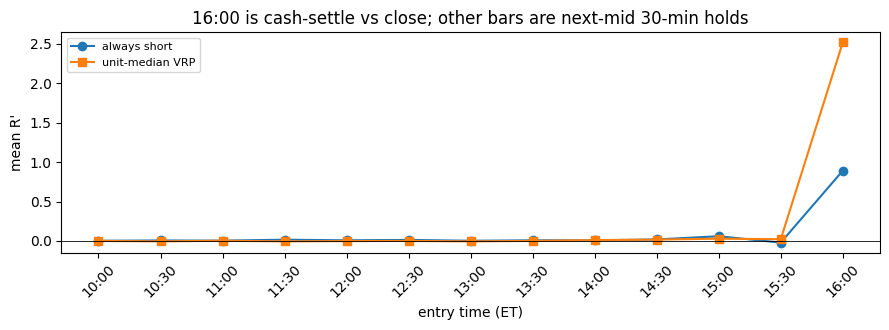

saved CSVs in C:\Users\james\CC Allowed\harxhar-0dte-professor\results\atm_straddle_intraday


In [11]:
clock_rows = []
for hhmm, g in work.groupby("hhmm", sort=True):
    for name, size in q.items():
        rp = (size * work["R"]).loc[g.index]
        st = asl.rule_row(rp, size.loc[g.index])
        clock_rows.append({"hhmm": hhmm, "rule": name, **st.to_dict()})
stab = pd.DataFrame(clock_rows)
stab.to_csv(OUT / "rule_by_entry_hhmm.csv", index=False)
print("always short by clock time")
print(stab[stab["rule"] == "always short"][
    ["hhmm", "n", "mean", "t_mean", "Sharpe_ann"]
].to_string(index=False))
print("unit-median by clock time")
print(stab[stab["rule"] == "unit-median VRP"][
    ["hhmm", "n", "mean", "t_mean", "Sharpe_ann", "pct_buy"]
].to_string(index=False))

hour_rows = []
for hr, g in work.groupby("hour"):
    for name, size in q.items():
        rp = (size * work["R"]).loc[g.index]
        st = asl.rule_row(rp, size.loc[g.index])
        hour_rows.append({"hour": int(hr), "rule": name, **st.to_dict()})
htab = pd.DataFrame(hour_rows)
htab.to_csv(OUT / "rule_by_entry_hour.csv", index=False)

fig, ax = plt.subplots(figsize=(9, 3.4))
for rule, marker in (("always short", "o"), ("unit-median VRP", "s")):
    sub = stab[stab["rule"] == rule]
    ax.plot(sub["hhmm"], sub["mean"], marker=marker, label=rule)
ax.axhline(0, color="k", lw=0.6)
ax.set_xlabel("entry time (ET)")
ax.set_ylabel("mean R'")
ax.set_title("16:00 is cash-settle vs close; other bars are next-mid 30-min holds")
ax.tick_params(axis="x", rotation=45)
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUT / "mean_by_entry_hhmm_as.png", dpi=120, bbox_inches="tight")
display(fig)
plt.close(fig)
print("saved CSVs in", OUT)
